# Behavior analysis, summary, and visualization

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import os 
import glob
import re
import shutil
from scipy.signal import butter, filtfilt
from scipy.signal import medfilt
from scipy.signal import savgol_filter

## Organize data

### access the data and format it
- get_txt_path: find all sessions (txt files)
- get_txt_df: read txt files and sort data into pandas df
- convert_timestamps; lick_detect: necessary text/data processing to make df

In [10]:
def get_txt_path(directory):
    '''
    This function returns any file under directory that has RoiSet.zip in the filename

    Parameters
    ----------
    directory : str
        The path to the directory to search.

    Returns
    -------
    txt_files : str or None
        The file path to all txt files under directory, or None if not found.
    '''
    # Search for RoiSet.zip in the directory
    txt_files = glob.glob(os.path.join(directory, '**', '*.txt'), recursive=True)
    # Check if any RoiSet.zip files were found
    if len(txt_files) == 0:
        print("No .txt files found.")
        return None
    return txt_files

def get_txt_df(filepath):
    if os.path.getsize(filepath) == 0:
        print(f"Skipping {filepath}: File is empty")
        return None  # Skip empty files

    #includes substantial preprocessing to make a useable dataframe!
    df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
    df = df.reset_index()
    #alt labels = df.columns[-2:]
    df.drop(labels=['index',2,3],axis=1,inplace=True) ##flag this, causing errors in new setup help
    df.rename(columns={0: 'Timestamp', 1: 'Print'}, inplace=True)
    #extract data from print statements
    df['Print'] = df['Print'].astype(str)
    df = df[~df['Print'].str.contains('Solenoid pin state')]
    df['Sensor'] = df['Print'].str.extract(r'(lick|bar)', expand=False)
    df['Value'] = df['Print'].str.extract(r'(\d+)', expand=False).astype(float)
    df['Solenoid'] = df['Print'].str.contains('Solenoid Activated').astype(bool)
    df.drop(labels=['Print'],axis=1,inplace=True)
    #remove rows where solenoid is false and sensor is nan
    df = df[~(df['Sensor'].isna() & (df['Solenoid'] == 0))]
    #df.dropna(axis=0,inplace=True)
    df = convert_timestamps(df)
    df = lick_detection(df)
    return df

def convert_timestamps(df):
    """
    Convert the Timestamp column to datetime format, ensuring the correct interpretation of hours, minutes, seconds, and milliseconds.
    """
    df['Timestamp'] = df['Timestamp'].str.strip()
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%H:%M:%S.%f')
    return df

def lick_detection(df, sensor='lick', percentile=0.1, m=2, min_val=15):
    """ detects lick when snesor value is m stdevs above the lowext x percentile 
    thanks chatgpt:)
    Add a boolean column 'Lick_Detected' to the DataFrame, indicating whether a lick was detected.

    Parameters:
    df (pd.DataFrame): The input DataFrame with lick data.
    sensor (str): The sensor to detect licks for, default is 'lick'.
    percentile (float): The percentile to use for the baseline, default is 10th percentile.
    stdev_multiplier (float): The number of standard deviations above the baseline to set the threshold, default is 2.

    Returns:
    pd.DataFrame: The DataFrame with an added 'Lick_Detected' boolean column.
    """
    # Filter the DataFrame to include only the relevant sensor data
    sensor_df = df[df['Sensor'] == sensor]
    # Calculate the baseline using the specified percentile
    baseline_value = sensor_df['Value'].quantile(percentile)
    # Calculate the standard deviation
    stdev_value = sensor_df['Value'].std()
    # Set the lick detection threshold
    threshold = baseline_value + m * stdev_value
    # Add a boolean column indicating whether each value exceeds the threshold
    df['Lick_Detected'] = False
    df.loc[df['Sensor'] == sensor, 'Lick_Detected'] = sensor_df['Value'] > threshold
    df.loc[df['Sensor'] == sensor, 'Lick_Detected'] = sensor_df['Value'] > min_val
    return df


### organize files into folders by animal_ID (with safetys to check current location before moving)

In [11]:
# Define the directory containing the files
source_dir = '//Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'
# Get a list of all items in the source directory
files = os.listdir(source_dir)
# Define a pattern to match the animal ID (3 or digits followed by 1 letter, 1 digit two letters 1 digit)
pattern = re.compile(r"(?:\d{3,4}[A-Z]|\d[A-Z]{2}\d)") 

# Process each file
for filename in files:
    # Skip if it's a directory
    if os.path.isdir(os.path.join(source_dir, filename)):
        continue
        
    match = pattern.match(filename)
    if match:
        animal_id = match.group(1)
        # Check if file is already in correct folder
        current_path = os.path.join(source_dir, filename)
        if os.path.dirname(current_path) == os.path.join(source_dir, animal_id):
            continue  # Skip if file is already in correct folder
            
        # Create a new directory for this animal ID if it doesn't exist
        save_dir = os.path.join(source_dir, animal_id)
        os.makedirs(save_dir, exist_ok=True)
        
        # Move the file to the new directory
        try:
            shutil.move(current_path, os.path.join(save_dir, filename))
            print(f"Moved {filename} to {animal_id} folder")
        except shutil.Error as e:
            print(f"Error moving {filename}: {e}")

###  delete empty text files

In [12]:
def delete_empty_txt_files(directory):
    for dirpath, _, filenames in os.walk(directory):
        for file in filenames:
            if file.endswith(".txt"):
                filepath = os.path.join(dirpath, file)
                # Check if the file is empty
                if os.path.getsize(filepath) == 0:
                    print(f"Deleting empty file: {filepath}")
                    os.remove(filepath)

# Example usage
directory_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'  # Replace with the path to your directory
delete_empty_txt_files(directory_path)


    #pattern = re.compile(r"(\d{3,4}[A-Z])_(.+?)_(\d{8})_(\d{6})") #old naming pattern
    pattern = re.compile(r"((?:\d{3,4}[A-Z]|\d[A-Z]{2}\d))_(.+?)_(\d{8})_(\d{6})") #looks for old or new naming pattern

## Summarize data

### update behavior summary 
cells below can be used to reprocess/recreate the summary.

In [43]:
def create_raw_behavior_summary_single(filepath):
    """
    Create a summary DataFrame for a single behavior file.
    
    Parameters
    ----------
    filepath : str
        Path to the behavior data file
    
    Returns
    -------
    pd.DataFrame
        Single-row DataFrame with behavioral metrics
    """
    try:
        df = get_txt_df(filepath)
        filename = os.path.basename(filepath)
        match = re.match(r"((?:\d{3,4}[A-Z]|\d[A-Z]{2}\d))_(.+?)_(\d{8})_(\d{6})", filename)
        
        if not match:
            raise ValueError('filename does not have correct pattern')
            
        animal_ID, stage, date, start_time = match.groups()
        
        # Calculate metrics
        bar_holds = df['Solenoid'].sum()
        num_licks = df['Lick_Detected'].sum()
        dur = df['Timestamp'].max() - df['Timestamp'].min()
        
        # Adjust date if session starts before 6 AM
        start_time = pd.to_datetime(start_time, format='%H%M%S')
        date = pd.to_datetime(date, format='%Y%m%d')
        if start_time.hour < 6:
            date -= pd.Timedelta(days=1)
            
        # Format date and time
        date = date.strftime('%Y-%m-%d')
        start_time = start_time.strftime('%H:%M:%S')
        
        return pd.DataFrame({
            'filename': [filename],
            'animal_ID': [animal_ID],
            'stage': [stage],
            'date': [date],
            'start': [start_time],
            'bar_holds': [bar_holds],
            'num_licks': [num_licks],
            'duration(min)': [dur.total_seconds()/60]
        })
        
    except Exception as e:
        print(f"Error processing file: '{filepath}'")
        print(f"Error details: {str(e)}")
        return None

In [44]:
def update_behavior_summary(data_path, save_path, force_reprocess=False, summary_type='raw'):
    """
    Update behavior summary by only processing new sessions and appending to existing summary.
    
    Parameters:
    -----------
    data_path : str
        Path to directory containing behavior data files
    save_path : str
        Path where the summary CSV should be saved
    force_reprocess : bool
        If True, reprocess all sessions regardless of existing summary
    summary_type : str
        'raw' or 'trial' to specify which summary type to update
        
    Returns:
    --------
    pd.DataFrame
        Updated behavior summary DataFrame
    """
    # Determine which summary file to use
    summary_file = "raw_behavior_summary.csv" if summary_type == 'raw' else "behavior_summary.csv"
    output_csv_path = os.path.join(save_path, summary_file)
    
    # Load existing summary if it exists
    existing_summary = None
    if not force_reprocess and os.path.exists(output_csv_path):
        existing_summary = pd.read_csv(output_csv_path)
        processed_files = set(existing_summary['filename'])
    else:
        processed_files = set()
    
    # Get all txt files
    txt_files = get_txt_path(data_path)
    if not txt_files:
        raise ValueError("No text files found in the specified directory")
    
    # Filter for only new files if not force_reprocessing
    new_files = []
    for txt in txt_files:
        filename = os.path.basename(txt)
        if force_reprocess or filename not in processed_files:
            new_files.append(txt)
    
    if not new_files and not force_reprocess:
        print("No new sessions to process.")
        return existing_summary
    
    # Process new files
    print(f"Processing {len(new_files)} new files...")
    summaries = []
    
    for i, txt in enumerate(new_files, 1):
        try:
            if summary_type == 'raw':
                summary = create_raw_behavior_summary_single(txt)
            else:
                summary = sess_performance(txt)
            summaries.append(summary)
            
            if i % max(1, len(new_files) // 10) == 0:
                print(f"Processed {i}/{len(new_files)} files ({(i/len(new_files))*100:.1f}%)")
                
        except Exception as e:
            filename = os.path.basename(txt)
            print(f"Error processing file: '{filename}'")
            print(f"Error details: {str(e)}")
            continue
    
    # Combine new summaries
    if summaries:
        new_summary = pd.concat(summaries, ignore_index=True, sort=False)
        
        # Add percent lick trials for trial-based summary
        if summary_type != 'raw':
            new_summary['p_lick_trials'] = 100 * new_summary['lick_trials'] / new_summary['total_trials']
        
        # Combine with existing summary if it exists
        final_summary = pd.concat([existing_summary, new_summary], ignore_index=True) if existing_summary is not None else new_summary
        
        # Sort by date and time
        final_summary['datetime'] = pd.to_datetime(final_summary['date'] + ' ' + final_summary['start'])
        final_summary = final_summary.sort_values('datetime').drop('datetime', axis=1)
        
        # Save updated summary
        try:
            os.makedirs(save_path, exist_ok=True)
            final_summary.to_csv(output_csv_path, index=False)
            print(f"Successfully saved updated measurements to {output_csv_path}")
        except Exception as e:
            print(f"Error saving file: {str(e)}")
        
        return final_summary
    
    return existing_summary

In [108]:
data_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'
save_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/data_summary'
behav_summary = update_behavior_summary(data_path, save_path, summary_type='trial')

Processing 6 new files...
Error processing file: 'test_test_20250228_085520.txt'
Error details: Filename 'test_test_20250228_085520.txt' does not match pattern
Error processing file: '277T_Reach_20241015_184100.txt'
Error details: Cannot set a DataFrame with multiple columns to the single column Lick_Detected


/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


Error processing file: '4934t_Reach_20241122_141952.txt'
Error details: Filename '4934t_Reach_20241122_141952.txt' does not match pattern
Error processing file: 'test_test_20250310_212427.txt'
Error details: Filename 'test_test_20250310_212427.txt' does not match pattern
Error processing file: '808T_LickReach_20240909_170833.txt'
Error details: Cannot set a DataFrame with multiple columns to the single column Lick_Detected
Error processing file: '808T_LickReach_20240910_180121.txt'
Error details: Cannot set a DataFrame with multiple columns to the single column Lick_Detected


In [102]:
behav_summary

,filename,animal_ID,stage,date,start,total_trials,lick_trials,duration_min,p_lick_trials
0,808T_Lick_20240813_223258.txt,808T,Lick,2024-08-13,22:32:58,123,86,2.540750,69.918699
1,808T_Lick_20240813_223605.txt,808T,Lick,2024-08-13,22:36:05,96,62,3.390633,64.583333
2,808T_Lick_20240813_223955.txt,808T,Lick,2024-08-13,22:39:55,62,4,1.161833,6.451613
3,806N_Lick_20240813_231545.txt,806N,Lick,2024-08-13,23:15:45,73,36,5.853467,49.315068
4,806N_Lick_20240813_232214.txt,806N,Lick,2024-08-13,23:22:14,135,19,4.999333,14.074074
...,...,...,...,...,...,...,...,...,...
365,1FB0_Reach2_20250311_212629.txt,1FB0,Reach2,2025-03-11,21:26:29,474,250,24.999933,52.742616
373,1FB2_Lick2_20250311_215729.txt,1FB2,Lick2,2025-03-11,21:57:29,23,15,0.658117,65.217391
372,1FB2_Reach2_20250311_215822.txt,1FB2,Reach2,2025-03-11,21:58:22,552,335,24.999917,60.688406
370,1FB2_Lick2_20250312_152426.txt,1FB2,Lick2,2025-03-12,15:24:26,29,22,0.845250,75.862069


In [39]:
data_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'
save_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/data_summary'
raw_behav_summary = update_behavior_summary(data_path, save_path, summary_type='raw')

Processing 74 new files...
Error processing file: '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/test_test_20250310_211157.txt'
Error details: filename does not have correct pattern
Error processing file: '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/test_test_20250310_135908.txt'
Error details: filename does not have correct pattern
Error processing file: '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/test_test_20250307_132629.txt'
Error details: filename does not have correct pattern
Error processing file: '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/test_test_20250310_211520.txt'
Error details: filename does not have correct pattern
Error processing file: '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/test_test_20250310_210627.txt'
Error details: filename does not have correct pattern
Error processing file: '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Tas

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, o

Processed 14/74 files (18.9%)
Error processing file: '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/770N/test_test_20250228_085520.txt'
Error details: filename does not have correct pattern


/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


Processed 21/74 files (28.4%)


...

Error processing file: '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/801N/test_test_20250310_212427.txt'
Error details: filename does not have correct pattern


/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


Processed 70/74 files (94.6%)


/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


Successfully saved updated measurements to /Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/data_summary/raw_behavior_summary.csv


In [40]:
raw_behav_summary.head()

,filename,animal_ID,stage,date,start,bar_holds,num_licks,duration(min)
214,808T_Lick_20240813_223258.txt,808T,Lick,2024-08-13,22:32:58,123,1268,2.540750
223,808T_Lick_20240813_223605.txt,808T,Lick,2024-08-13,22:36:05,96,5289,3.390633
218,808T_Lick_20240813_223955.txt,808T,Lick,2024-08-13,22:39:55,62,48,1.161833
116,806N_Lick_20240813_231545.txt,806N,Lick,2024-08-13,23:15:45,73,252,5.853467
122,806N_Lick_20240813_232214.txt,806N,Lick,2024-08-13,23:22:14,135,156,4.999333


### create raw behavior data summary

In [13]:
def create_raw_behavior_summary(data_path, save_path=None, max_files=None):
    """
    Create a summary DataFrame of behavioral metrics from text files. 
    minimally processed data, no trial structure implemented
    
    Parameters
    ----------
    data_path : str
        Path to directory containing behavior data files
    save_path : str, optional
        Path to save CSV output. If None, won't save to file
    max_files : int, optional
        Maximum number of files to process (for testing)
    
    Returns
    -------
    pd.DataFrame
        Summary DataFrame with behavioral metrics
    """
    # Get list of behavior files
    txt_files = get_txt_path(data_path)
    pattern = re.compile(r"((?:\d{3,4}[A-Z]|\d[A-Z]{2}\d))_(.+?)_(\d{8})_(\d{6})") #looks for old or new naming pattern
    behav_df = pd.DataFrame()
    
    for i, txt in enumerate(txt_files):
        if max_files and i >= max_files:
            break
            
        filename = os.path.basename(txt)
        try:
            # Parse filename and get data
            df = get_txt_df(txt)
            match = pattern.match(filename)
            if not match:
                raise ValueError('filename does not have correct pattern')
                
            animal_ID, stage, date, start_time = match.groups()
            
            # Calculate metrics
            bar_holds = df['Solenoid'].sum()
            num_licks = df['Lick_Detected'].sum()
            dur = df['Timestamp'].max() - df['Timestamp'].min()
            
            # Adjust date if session starts before 6 AM
            start_time = pd.to_datetime(start_time, format='%H%M%S')
            date = pd.to_datetime(date, format='%Y%m%d')
            if start_time.hour < 6:
                date -= pd.Timedelta(days=1)
                
            # Format date and time
            date = date.strftime('%Y-%m-%d')
            start_time = start_time.strftime('%H:%M:%S')
            
            # Create summary row
            df_ = pd.DataFrame({
                'filename': [filename],
                'animal_ID': [animal_ID],
                'stage': [stage],
                'date': [date],
                'start': [start_time],
                'bar_holds': [bar_holds],
                'num_licks': [num_licks],
                'duration(min)': [dur.total_seconds()/60]
            })
            behav_df = pd.concat([behav_df, df_], sort=False, ignore_index=True)
            
        except Exception as e:
            print(f"Error processing file: '{filename}' Error: {e}")
            continue

    # Save to CSV if path provided
    if save_path:
        output_csv_path = os.path.join(save_path, "raw_behavior_summary.csv")
        behav_df.to_csv(output_csv_path, index=False)
        print(f"Saved measurements to {output_csv_path}")
        
    return behav_df

In [8]:
# create raw behavior summary
data_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'
save_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/data_summary'
behav_df = create_raw_behavior_summary(data_path, save_path)

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, o

Error processing file: 'test_test_20250228_085520.txt' Error: filename does not have correct pattern


/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, o

Error processing file: '4934t_Reach_20241122_141952.txt' Error: filename does not have correct pattern


/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, o

Saved measurements to /Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/data_summary/raw_behavior_summary.csv


### create trial-session based data summary

In [17]:
#functions to get by trial and by session performance
'''
    note, trials are being identified by when the solenoid open condition was activated, not by when the condition was met 
    ie the conditions are tested by arduino to enable solenoid open, and we are trusting this and just saying when arduino says bar was held long enough this is a trial. 
    but true trial start time would depend on when the mouse started to hold the bar, timing from last water droplet, etc. 
'''

def trial_lick_detect(row,df):
    '''
    row : row of pandas df
    has trial start and trial end time
    df: this should be the df extracted from txt file with all sensor data. (output of get_txt_df+some things in trial_performance)
    filters parent df to individual trials using start and end times
    records if any lick was detected during that trial period
    '''
    mask = (df['Timestamp'] >= row['trial_start']) & (df['Timestamp']<= row['trial_end'])
    return int(df.loc[mask,'Lick_Detected'].any())

def trial_performance(filepath, min_bar_hold = 1.5, max_trial_dur = 10):
    '''
    Parameters:
    -----------
    filepath : str
        Path to the data file
    min_bar_hold : float
        Minimum time (in seconds) the bar must be held (used as fallback duration for last trial)
        should be reported at beginning of session txt file. 
    max_trial_dur : float
        Maximum allowed trial duration in seconds
        
    Notes:
    ------
    - Trial start is when solenoid activates (indicating successful bar hold)
        - in get_txt_df 'solenoid activated' is reported once per trial. so luckily this is an okay metric to use
    - Trial end is the earlier of:
        a) The start of the next trial
        b) max_trial_dur seconds after trial start
    - For the last trial, uses min_bar_hold as the duration since there's no next trial
    - =lick_detected/total_trials will tell us "of the succesful bar holds, how many were succesful reaches"
    '''
    df = get_txt_df(filepath)
    
    # Get timestamps of all solenoid activations (trial starts)
    trial_start = df[df['Solenoid']==True]['Timestamp'].reset_index(drop=True)
    
    # Calculate time between successive solenoid activations
    trial_dur = trial_start.diff().shift(-1)  # Time until next trial starts
    trial_dur = trial_dur.dt.total_seconds().fillna(min_bar_hold)  # Use min_bar_hold for last trial
    
    # Calculate two potential end times:
    trial_end_est = trial_start + pd.to_timedelta(trial_dur, unit='s')  # Based on next trial
    trial_end_max = trial_start + pd.to_timedelta(max_trial_dur, unit='s')  # Based on max duration
    
    # Take the earlier of the two end times
    trial_end = trial_end_est.combine(trial_end_max, min)
    
    # Create trial dataframe
    trial_df = pd.DataFrame({
        'trial_start': trial_start,
        'trial_end': trial_end
    })
    
    # Add whether a lick was detected during each trial
    trial_df['Lick_Detected'] = trial_df.apply(trial_lick_detect, axis=1, df=df)
    
    return trial_df

def sess_performance(filepath, min_bar_hold=1.5, max_trial_dur=10):
    '''
    the session start and session end time is incorrect here. it is chosen based off first solenoid activation
    but the session could have lasted much longer than the trial_start_end min/max times. 
    we need to just go into the txt file and get first and last timestamps (get_txt_df_)

    '''
    df = get_txt_df(filepath)
    trial_df = trial_performance(filepath, min_bar_hold, max_trial_dur)
    total_trials = len(trial_df)
    lick_trials = trial_df['Lick_Detected'].sum()
    
    dur = (df['Timestamp'].max() - df['Timestamp'].min())
    session_duration = dur.total_seconds()/60
    
    filename = os.path.basename(filepath)
    match = re.match(r"((?:\d{3,4}[A-Z]|\d[A-Z]{2}\d))_(.+?)_(\d{8})_(\d{6})", filename)
    if match:
        animal_ID, stage, date, start_time = match.groups()
    else:
        raise ValueError(f"Filename '{filename}' does not match pattern")
    
    start_time = pd.to_datetime(start_time, format='%H%M%S')
    if start_time.hour < 6:
        date = pd.to_datetime(date, format='%Y%m%d') - pd.Timedelta(days=1)
    else:
        date = pd.to_datetime(date, format='%Y%m%d')
    
    return pd.DataFrame({
        'filename': [filename],
        'animal_ID': [animal_ID],
        'stage': [stage],
        'date': [date.strftime('%Y-%m-%d')],
        'start': [start_time.strftime('%H:%M:%S')],
        'total_trials': [total_trials],
        'lick_trials': [lick_trials],
        'duration_min': [session_duration]
    })

In [18]:
def create_behavior_summary(data_path, save_path):
    """
    Create a summary of behavioral data from text files and save to CSV.
    
    Parameters:
    -----------
    data_path : str
        Path to directory containing the behavior data files
    save_path : str
        Path where the summary CSV should be saved
        
    Returns:
    --------
    pd.DataFrame
        DataFrame containing the behavior summary
    """
    txt_files = get_txt_path(data_path)
    
    if not txt_files:
        raise ValueError("No text files found in the specified directory")
    
    pattern = re.compile(r"((?:\d{3,4}[A-Z]|\d[A-Z]{2}\d))_(.+?)_(\d{8})_(\d{6})") 
    
    # Pre-allocate list for better memory efficiency
    summaries = []
    total_files = len(txt_files)
    
    print(f"Processing {total_files} files...")
    
    for i, txt in enumerate(txt_files, 1):
        try:
            # Use the session performance function to get summarized metrics
            sess_summary = sess_performance(txt)
            summaries.append(sess_summary)
            
            # Progress update every 10% of files
            if i % max(1, total_files // 10) == 0:
                print(f"Processed {i}/{total_files} files ({(i/total_files)*100:.1f}%)")
                
        except Exception as e:
            filename = os.path.basename(txt)
            print(f"Error processing file: '{filename}'")
            print(f"Error details: {str(e)}")
            continue
    
    # More efficient concatenation of all summaries at once
    behav_summary = pd.concat(summaries, ignore_index=True, sort=False)
    
    #add percent lick trials (like hit rate)
    behav_summary['p_lick_trials'] = 100*behav_summary['lick_trials']/behav_summary['total_trials']

    # Save to csv with error handling
    output_csv_path = os.path.join(save_path, "behavior_summary.csv")
    
    try:
        os.makedirs(save_path, exist_ok=True)
        behav_summary.to_csv(output_csv_path, index=False)
        print(f"Successfully saved measurements to {output_csv_path}")
    except Exception as e:
        print(f"Error saving file: {str(e)}")
    
    return behav_summary

### only run below if you have updated something in method of behavior summary, and you want to re-run behav summary on all sessions.

In [19]:
data_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'
save_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/data_summary'
behav_summary = create_behavior_summary(data_path, save_path)

Processing 318 files...
Error processing file: 'test_test_20250305_215604.txt'
Error details: Filename 'test_test_20250305_215604.txt' does not match pattern


/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, o

Error processing file: 'test_test_20250228_085520.txt'
Error details: Filename 'test_test_20250228_085520.txt' does not match pattern


/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


Processed 31/318 files (9.7%)


...

Error processing file: 'test_test_20250306_133710.txt'
Error details: Filename 'test_test_20250306_133710.txt' does not match pattern


/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, o

Processed 310/318 files (97.5%)


/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, o

Successfully saved measurements to /Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/data_summary/behavior_summary.csv


## Analysis

In [41]:
filepath = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/381B/381B_Reach2_20250226_131444.txt'
df = get_txt_df(filepath)
df.head()

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


,Timestamp,Sensor,Value,Solenoid,Lick_Detected
4,1900-01-01 13:14:46.994,bar,0.0,False,False
5,1900-01-01 13:14:46.995,lick,0.0,False,False
7,1900-01-01 13:14:47.002,bar,4.0,False,False
8,1900-01-01 13:14:47.002,lick,8.0,False,False
10,1900-01-01 13:14:47.006,bar,4.0,False,False


In [78]:
def create_resampled_timeseries(df, freq='1S'):
    """
    Create evenly sampled binary time series from DataFrame timestamps.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame from get_txt_df with 'Timestamp' and 'Lick_Detected' columns
    freq : str
        Sampling frequency (default: '1S' for 1 second)
        
    Returns:
    --------
    pd.Series
        Resampled binary time series with regular intervals, starting form 0 to session end time. 
    """
    session_start = df['Timestamp'].min()
    # Set timestamp as index
    df.set_index('Timestamp', inplace=True)
    
    # Resample to regular intervals
    # Using max() will preserve any licks in the bin
    resampled = df['Lick_Detected'].resample(freq).max().fillna(False)
    time_from_start = (resampled.index - session_start).total_seconds()
    resampled.index = time_from_start
    return resampled.astype(int)

In [99]:
def plot_lick_time_conv(filepath, freq='1S', window_minutes=10):
    #get session data
    df = get_txt_df(filepath)

    # Create resampled binary time series (1 second intervals)
    binary_series = create_resampled_timeseries(df, freq)

    #account for sampling freq in time 
    freq_seconds = pd.Timedelta(freq).total_seconds()
    # Create square wave (N-minute window)
    window_size = int(window_minutes * 60/freq_seconds)  # number of seconds in window
    square_wave = np.ones(window_size)

    # Convolve the series with square wave
    convolved = np.convolve(binary_series, square_wave, mode='valid')
    time_minutes = binary_series.index * freq_seconds/60
    
    #get peak time
    peak_time = np.argmax(convolved) * pd.Timedelta(freq).total_seconds()
    print(f"peak time: {peak_time} seconds")
    
    # Plot original and convolved signals
    fig, (ax1,ax2) = plt.subplots(2,1,figsize=(15,6))

    ax1.plot(time_minutes, binary_series.values, 'b.')
    ax1.set_title('Resampled Lick Events (1s bins)')
    ax1.set_ylabel('Lick Detected')

    ax2.plot(convolved)
    ax2.set_title('Convolved Signal (Number of licks in sliding window)')
    ax2.set_ylabel('Lick Count')
    ax2.set_xlabel('Time (seconds from start)')

    plt.tight_layout()
    plt.show()

    print("warning: this function does not correctly apply any sampling frequency to the plot. it only works for 1s bins.")
    return fig, (ax1,ax2)

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


peak time: 2.0 seconds


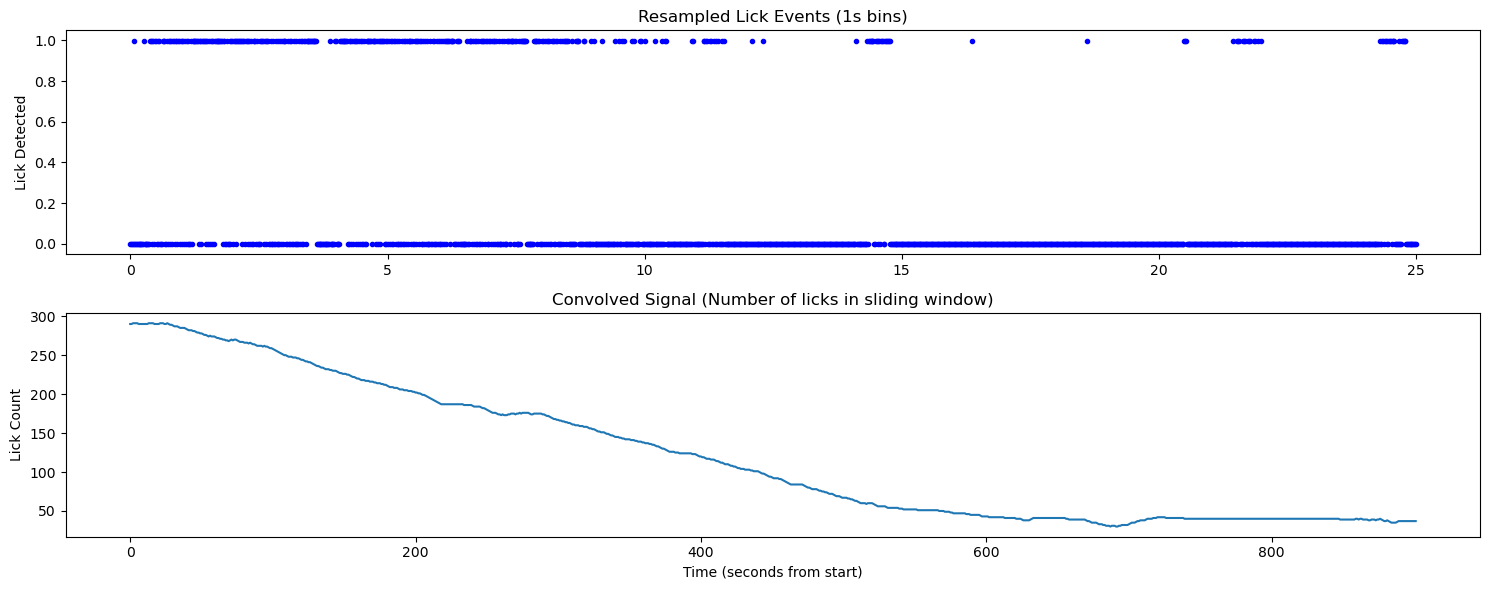

(<Figure size 1500x600 with 2 Axes>,
 (<Axes: title={'center': 'Resampled Lick Events (1s bins)'}, ylabel='Lick Detected'>,
  <Axes: title={'center': 'Convolved Signal (Number of licks in sliding window)'}, xlabel='Time (seconds from start)', ylabel='Lick Count'>))

In [100]:
filepath = '/Users/emmaodom/MIT Dropbox/Emma Odom/Emma/Reach_Task_Master/lick_reaching_data/1FB1/1FB1_Reach2_20250311_205407.txt'
plot_lick_time_conv(filepath, freq='1S', window_minutes=10)

## Visualization

In [103]:
def downsample(data, factor):
    return data[::factor]

def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def median_filter(data, kernel_size=3):
    return medfilt(data, kernel_size=kernel_size)

def get_sampling_rate(df):
    #gets me a sampling rate for each sensor! direct chatgpt, but hey it works.
    if not pd.api.types.is_datetime64_any_dtype(df['Timestamp']):
        # Step 1: Clean the 'Timestamp' column by stripping whitespace
        df['Timestamp'] = df['Timestamp'].str.strip()
        # Step 2: Convert 'Timestamp' column to datetime with error handling
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%H:%M:%S.%f', errors='coerce')
        # Check for any rows where the conversion failed (i.e., where Timestamp is NaT)
        failed_conversions = df[df['Timestamp'].isna()]
        if not failed_conversions.empty:
            print("Rows with failed Timestamp conversions:")
            print(failed_conversions)
    # Step 3: Calculate time differences for each sensor if conversion was successful
    df['Time_Diff'] = df.groupby('Sensor')['Timestamp'].diff()
    # Step 4: Calculate the sampling frequency for each sensor
    sampling_freq = df.groupby('Sensor')['Time_Diff'].apply(lambda x: 1 / x.mean().total_seconds())
    # Display the results
    #df.drop(['Time_Diff'])
    df.drop(['Time_Diff'], axis=1, inplace=True, errors='ignore')
    print(sampling_freq)
    return(sampling_freq)


In [104]:
#maybe downsample before simple visualizaiton plots... 
#cant downsample lick and bar the same factpr (temporal res of lick sensor is way more important than the bar temporal resolution)
import matplotlib.dates as mdates
def basic_plot(df, animal_ID, date, stage, dots = True, which_dots = 'Solenoid'):
    #sort data by sensor type and lineplot 
    lick_df = df[df['Sensor']=='lick'].iloc[::10, :]
    bar_df = df[df['Sensor']=='bar'].iloc[::40, :]
    sns.lineplot(data=lick_df,x='Timestamp',y='Value',label='lick')
    sns.lineplot(data=bar_df,x='Timestamp',y='Value',label='bar')
    #dots for solenoid activations
    if dots:
        dots_df = df[df[which_dots]==True]
        scale = 1.2*bar_df['Value'].max()
        y_ = scale*np.ones_like(dots_df['Value'])
        plt.scatter(dots_df['Timestamp'],y_,color='red',s=2,label=which_dots,zorder=5)
    #set x-ticks 
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45) 
    #label things
    plt.title(f"{stage} Animal {animal_ID} - {date}")
    plt.legend()
    plt.show()   
#example/test call
#basic_plot(df,animal_ID,date,stage='Lick', dots=True, which_dots='Lick_Detected') 

def smoothed_plot(df, animal_ID, date, stage,order=2,kernel_size=30,dots = True, which_dots = 'Solenoid',save=False, directory='none'):
    #fs_lick,fs_bar,cutoff_freq=0.2 used to be inputs for low-pass filter
    # Apply downsampling
    lick_df = df[df['Sensor'] == 'lick'].iloc[::10, :]
    bar_df = df[df['Sensor'] == 'bar'].iloc[::40, :]
    
    # Apply low-pass filter to smooth the data
    #lick_df['Smoothed_Value'] = butter_lowpass_filter(lick_df['Value'], cutoff=cutoff_freq, fs=fs_lick,order=order)
    # Apply a Savitzky-Golay filter
    lick_df['Smoothed_Value'] = savgol_filter(lick_df['Value'], window_length=7, polyorder=2)
    bar_df['Smoothed_Value'] = median_filter(bar_df['Value'], kernel_size=kernel_size)
    
    # Plotting
    sns.lineplot(data=lick_df, x='Timestamp', y='Smoothed_Value', label='lick')
    sns.lineplot(data=bar_df, x='Timestamp', y='Smoothed_Value', label='bar')
    #scatter
    if dots:
        dots_df = df[df[which_dots]==True]
        scale = 1.2*bar_df['Value'].max()
        y_ = scale*np.ones_like(dots_df['Value'])
        plt.scatter(dots_df['Timestamp'],y_,color='red',s=2,label=which_dots,zorder=5)
        
    #set x-ticks 
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45) 
    plt.title(f"{stage} Animal {animal_ID} - {date} \n bar: median_filter lick: savgol_filter")
    plt.legend()
    if save:
        save_path = directory +'/pdf/' + f'{animal_ID}_smoothed_lick_bar_plot.pdf'
        plt.savefig(save_path, format = 'pdf')
    plt.show()


### get unique animal IDs

In [105]:
# Get unique animal IDs and sort them
animal_ids = sorted(behav_summary['animal_ID'].unique())
print("Available animal IDs:", animal_ids)

Available animal IDs: ['1FB0', '1FB1', '1FB2', '277N', '277T', '381B', '390L', '402R', '4432T', '4844T', '4934T', '770N', '771N', '772N', '801N', '802T', '806N', '807T', '808T']


### performance summary across days

In [106]:
def plot_animal_lick_trials(behav_summary, animal_id, min_duration=10, stage_filter=None):
    """
    Process and plot lick trials data for a single animal
    
    Parameters:
    -----------
    behav_summary : pd.DataFrame
        The behavior summary dataframe
    animal_id : str
        The animal ID to plot
    min_duration : int
        Minimum session duration in minutes to include (default: 10)
    stage_filter : str, optional
        Filter sessions based on stage name:
        - 'lick': only plot sessions where stage contains 'lick'
        - 'reach': only plot sessions where stage contains 'reach'
        - None: plot all sessions
    """
    # Filter and sort data
    animal_data = behav_summary[behav_summary['animal_ID'] == animal_id]
    animal_data = animal_data[animal_data['duration_min'] > min_duration]
    
    # Apply stage filter if specified
    if stage_filter == 'lick':
        animal_data = animal_data[animal_data['stage'].str.lower().str.contains('lick')]
    elif stage_filter == 'reach':
        animal_data = animal_data[animal_data['stage'].str.lower().str.contains('reach')]
    elif stage_filter is not None:
        raise ValueError("stage_filter must be 'lick', 'reach', or None")
    
    animal_data = animal_data.sort_values(by='date')
    
    # Create plot
    plt.figure(figsize=(4, 4))
    sns.scatterplot(data=animal_data, x='date', y='lick_trials', hue='stage')
    plt.title(f'Animal {animal_id} - {stage_filter if stage_filter else "all"} sessions')
    plt.xticks(rotation=45)

    plt.tight_layout()
    
    return animal_data

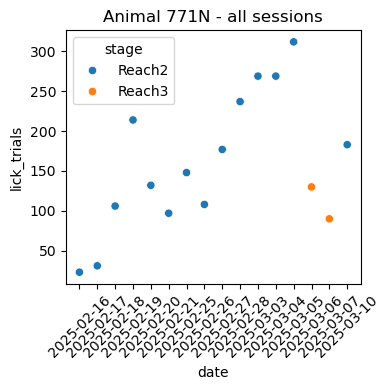

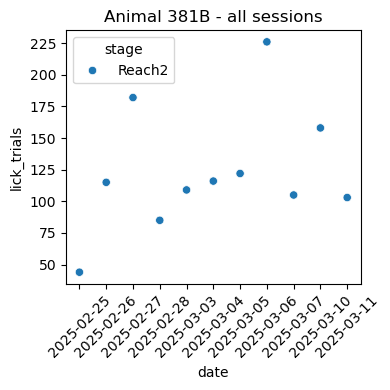

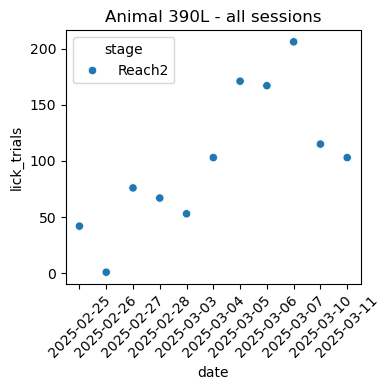

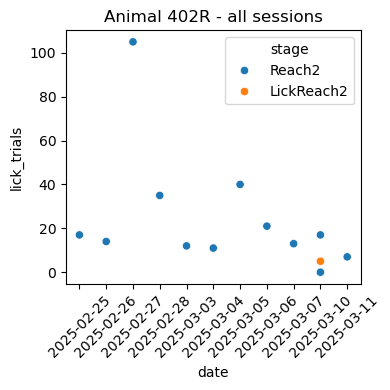

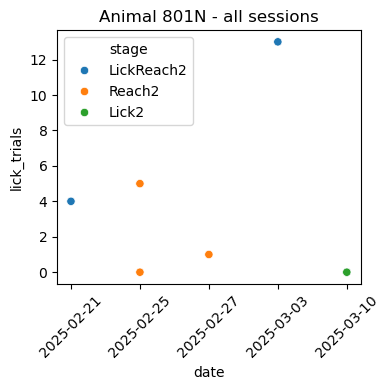

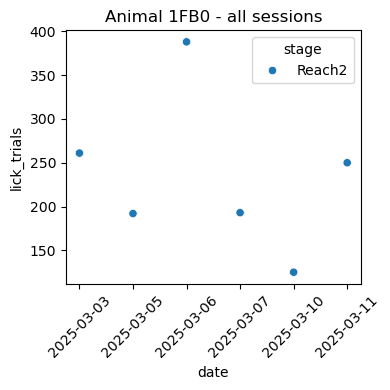

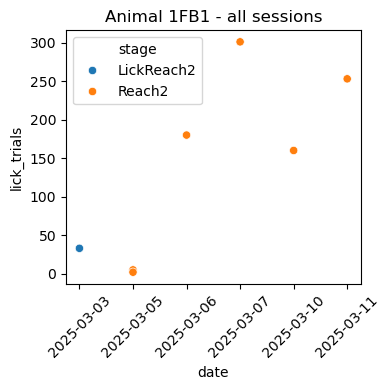

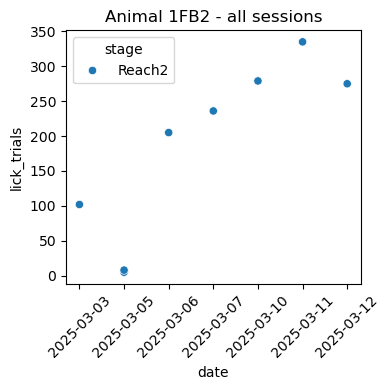

In [109]:
# Plot all animals
current_animals = ['771N','381B','390L','402R','801N','1FB0','1FB1','1FB2']
for animal_id in current_animals:
    plot_animal_lick_trials(behav_summary, animal_id)
    plt.show()

### specific session plot

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_21061/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


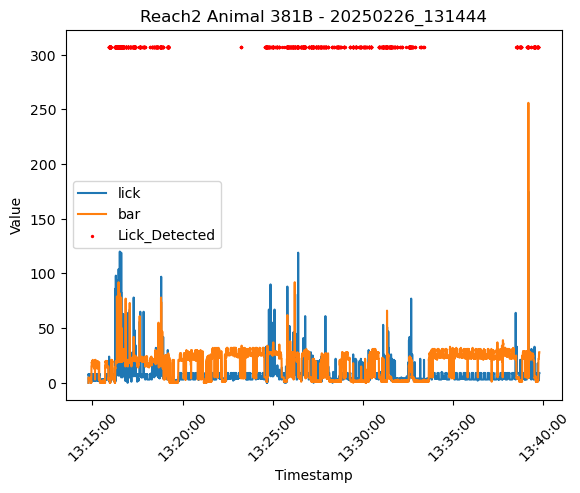

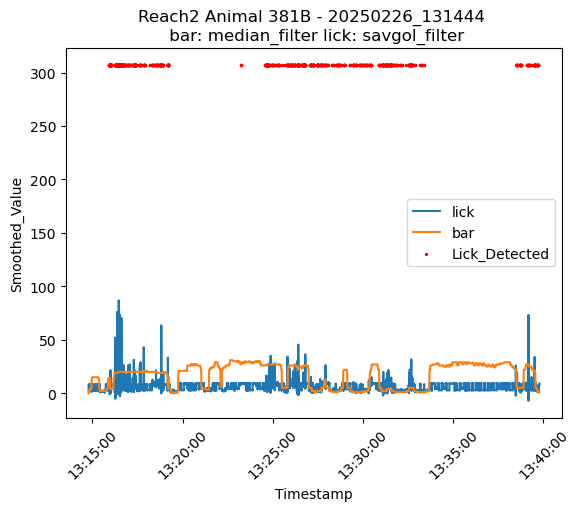

In [ ]:
filepath = '/Users/emmaodom/MIT Dropbox/Emma Odom/Emma/Reach_Task_Master/lick_reaching_data/381B/381B_Reach2_20250226_131444.txt'
#good example file #'/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/277T/277T_LickReach_20240911_212833.txt'
filename = os.path.basename(filepath)
df = get_txt_df(filepath)
# Regular expression to extract animal_ID, stage, and date
pattern = re.compile(r"((?:\d{3,4}[A-Z]|\d[A-Z]{2}\d))_(.+?)_(\d{8})_(\d{6})") #looks for old or new naming pattern
# Extracting the components from the filename
match = pattern.match(filename)
if match:
    animal_ID = match.group(1)
    stage = match.group(2)
    date = match.group(3)
basic_plot(df, animal_ID = animal_ID, date=date, stage=stage, dots=True, which_dots='Lick_Detected')
save_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/visualizations'
smoothed_plot(df, animal_ID = animal_ID, date=date, stage=stage, kernel_size = 99, dots=True, which_dots='Lick_Detected',save=True,directory=save_path)

### all sessions plot

In [110]:
def plot_animal_sessions(animal_id, data_dir, plot_type='basic', session_type=None, plots_per_row=4):
    """
    Create subplots of all sessions for a given animal, ordered by date.
    
    Parameters
    ----------
    animal_id : str
        Animal ID (e.g. '402R')
    data_dir : str
        Base directory containing behavior data
    plot_type : str, optional
        'basic' or 'smoothed' (default: 'basic')
    session_type : str, optional
        'Lick' or 'Reach' to filter sessions, or None for all sessions
    plots_per_row : int, optional
        Number of plots per row (default: 4)
    
    Returns
    -------
    fig : matplotlib figure
        The figure containing all subplots
    """
    # Get animal directory
    animal_dir = os.path.join(data_dir, animal_id)
    if not os.path.exists(animal_dir):
        raise ValueError(f"Directory not found for animal {animal_id}")
        
    # Get all txt files for this animal
    txt_files = glob.glob(os.path.join(animal_dir, '*.txt'))
    
    # Parse filenames and sort by date
    sessions = []
    pattern = re.compile(r"((?:\d{3,4}[A-Z]|\d[A-Z]{2}\d))_(.+?)_(\d{8})_(\d{6})") 
    
    
    for txt in txt_files:
        filename = os.path.basename(txt)
        match = pattern.match(filename)
        if match:
            animal_ID, stage, date, time = match.groups()
            # Filter by session type if specified
            if session_type and session_type not in stage:
                continue
            sessions.append({
                'filepath': txt,
                'date': date,
                'time': time,
                'stage': stage
            })
    
    # Sort sessions by date and time
    sessions.sort(key=lambda x: (x['date'], x['time']))
    
    # Calculate grid dimensions
    n_sessions = len(sessions)
    if n_sessions == 0:
        print(f"No matching sessions found for animal {animal_id}")
        return None
    
    n_rows = (n_sessions + plots_per_row - 1) // plots_per_row  # Ceiling division
    
    # Create figure with appropriate size
    # Make each subplot 5x4 inches
    fig = plt.figure(figsize=(5*plots_per_row, 4*n_rows))
    
    # Create subplots
    for i, session in enumerate(sessions):
        # Calculate subplot position
        row = i // plots_per_row
        col = i % plots_per_row
        plt.subplot(n_rows, plots_per_row, i + 1)
        
        try:
            df = get_txt_df(session['filepath'])
            if plot_type == 'basic':
                basic_plot(df, animal_id, session['date'], session['stage'], 
                         dots=True, which_dots='Lick_Detected')
            else:  # smoothed
                smoothed_plot(df, animal_id, session['date'], session['stage'],
                           kernel_size=99, dots=True, which_dots='Lick_Detected')
        except Exception as e:
            plt.text(0.5, 0.5, f"Error processing session:\n{str(e)}", 
                    ha='center', va='center')
    
    # If the last row is incomplete, remove empty subplots
    for j in range(i + 1, n_rows * plots_per_row):
        ax = plt.subplot(n_rows, plots_per_row, j + 1)
        ax.remove()
    
    # Adjust layout
    plt.tight_layout()
    return fig

# Example usage:
# data_dir = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'
# fig = plot_animal_sessions('402R', data_dir, plot_type='basic', session_type='Reach', plots_per_row=4)
# plt.show()

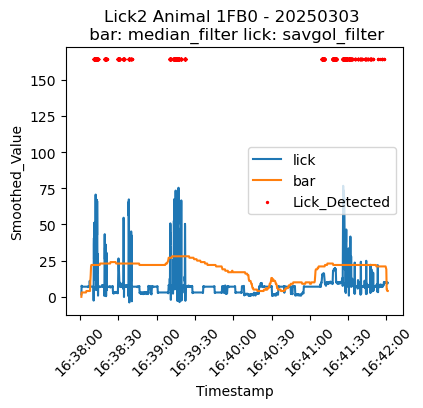

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


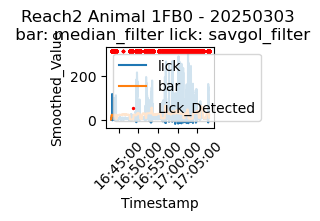

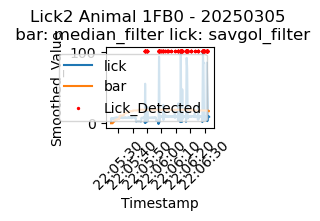

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


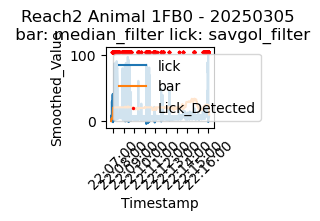

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


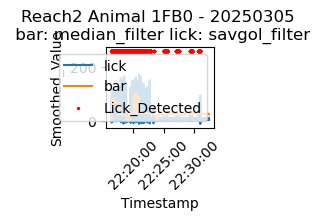

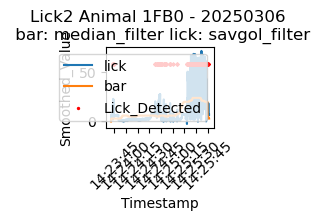

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


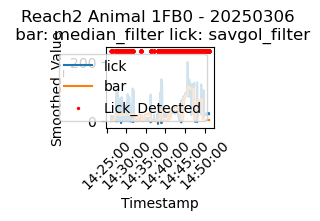

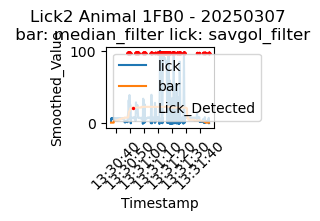

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


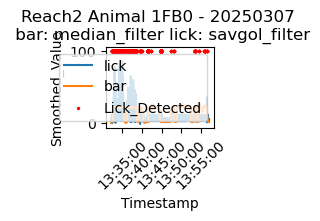

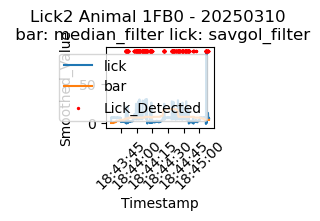

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


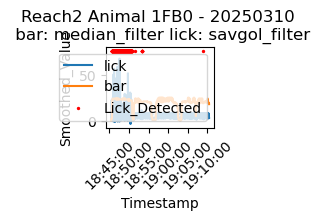

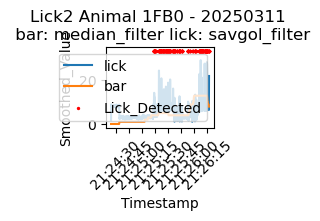

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/299707548.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


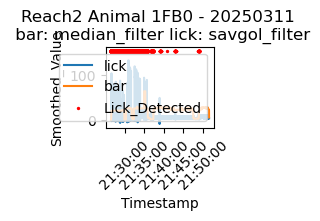

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_4431/75939844.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 640x480 with 0 Axes>

In [115]:
animal_id = '1FB0'
data_dir = '/Users/emmaodom/MIT Dropbox/Emma Odom/Emma/Reach_Task_Master/lick_reaching_data'
fig = plot_animal_sessions(animal_id, data_dir, plot_type='smoothed', session_type=None, plots_per_row=4)
fig.show()